Dataset 1 - E (Trapezoidal, direct): 15979.02 degF*s


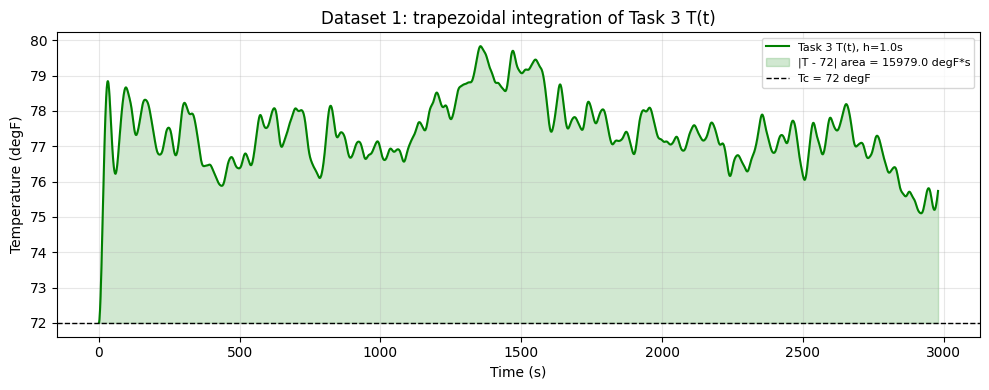

Dataset 2 - E (Trapezoidal, direct): 31922.70 degF*s


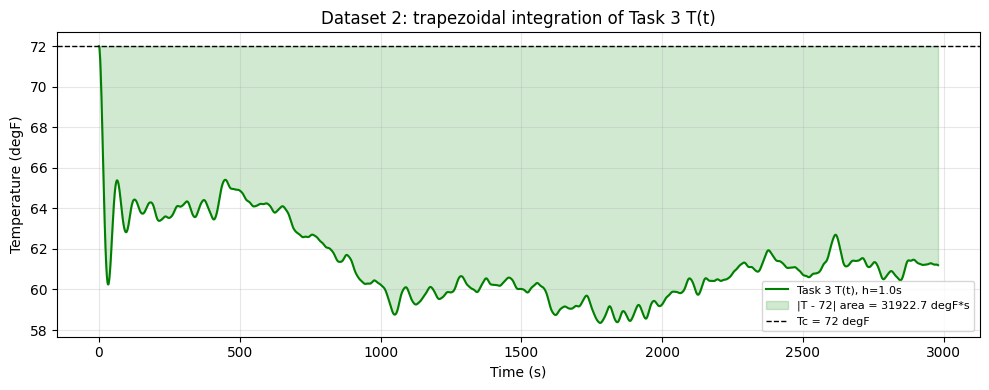

Dataset 3 - E (Trapezoidal, direct): 24919.20 degF*s


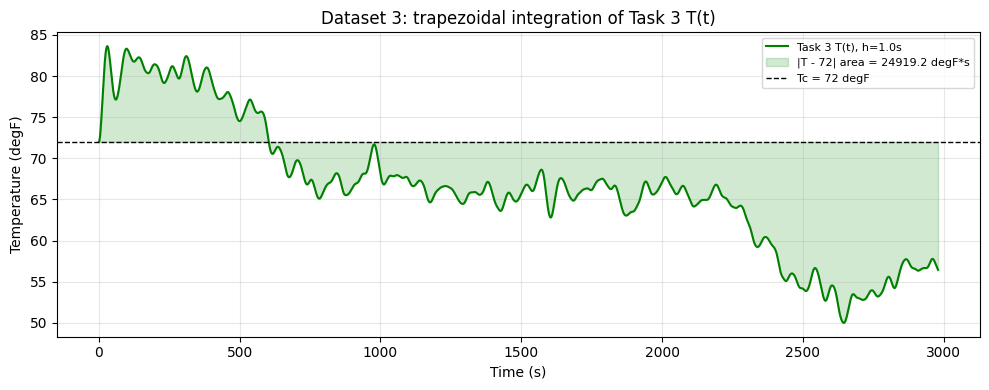

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def load_task3_definitions(notebook_path='task3.ipynb'):
    """Load Task 3 data and solver definitions without running Task 3 plots."""
    notebook = json.loads(Path(notebook_path).read_text(encoding='utf-8'))
    code = '\n'.join(
        ''.join(cell.get('source', []))
        for cell in notebook['cells']
        if cell.get('cell_type') == 'code'
    )
    code = code.split('\nfor theta_data, name in zip(datasets, dataset_names):')[0]
    namespace = {}
    exec(code, namespace)
    return namespace


_task3 = load_task3_definitions()
datasets = _task3['datasets']
dataset_names = _task3['dataset_names']
solve_task3 = _task3['solve_task3']
alpha = _task3['alpha']
k = _task3['k']

Tc = 72.0
h = 1.0

trapz = getattr(np, 'trapezoid', np.trapz)

for theta_data, name in zip(datasets, dataset_names):
    t_solver, T_solver, _ = solve_task3(theta_data, h=h, alpha=alpha, k=k)

    E_trap = trapz(np.abs(T_solver - Tc), t_solver)
    print(f'{name} - E (Trapezoidal, direct): {E_trap:.2f} degF*s')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_solver, T_solver, color='green', linewidth=1.5,
            label=f'Task 3 T(t), h={h}s')
    ax.fill_between(t_solver, Tc, T_solver, color='green', alpha=0.18,
                    label=f'|T - {Tc:.0f}| area = {E_trap:.1f} degF*s')
    ax.axhline(Tc, color='black', linestyle='--', linewidth=1,
               label=f'Tc = {Tc:.0f} degF')
    ax.set_title(f'{name}: trapezoidal integration of Task 3 T(t)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Temperature (degF)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
